[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter2_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 2: Market Efficiency, from EMH to Adaptive Markets

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces every chart and table of Lecture 2 on real daily data: 13 equity indices (2000–2026), Bitcoin, Ethereum and EUR/RON.

In [1]:
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from scipy.special import gammaln
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
GROUP_COL = {'Developed': MainBlue, 'Emerging/frontier': IDAred, 'Crypto': Amber, 'FX': Forest}

SEED = 42
TABLE_DIR = '.'


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import tempfile
TABLE_DIR = tempfile.gettempdir()   # tables are written to a temporary folder


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026.
- Equity indices: weekdays only, days with an unchanged close (filled holidays) removed.
- Crypto trades 7 days a week; EUR/RON is the BNR official reference rate.
- Each series is analysed on its own calendar.

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# nume -> (simbol, eticheta, grup, data de start, zile pe an)
MARKETS = {
    'sp500':  ('GSPC.INDX',     'S&P 500 (US)',          'Developed', '2000-01-01', 252),
    'stoxx':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Developed', '2000-01-01', 252),
    'nikkei': ('N225.INDX',     'Nikkei 225 (Japan)',    'Developed', '2000-01-01', 252),
    'hsi':    ('HSI.INDX',      'Hang Seng (HK)',        'Developed', '2000-01-01', 252),
    'bet':    ('BET',           'BET (Romania)',         'Emerging/frontier', '2000-01-01', 252),
    'wig20':  ('WIG20.INDX',    'WIG20 (Poland)',        'Emerging/frontier', '2000-01-01', 252),
    'bux':    ('BUX.INDX',      'BUX (Hungary)',         'Emerging/frontier', '2000-01-01', 252),
    'px':     ('PX.INDX',       'PX (Czechia)',          'Emerging/frontier', '2000-01-01', 252),
    'xu100':  ('XU100.INDX',    'BIST 100 (Turkey)',     'Emerging/frontier', '2000-01-01', 252),
    'bvsp':   ('BVSP.INDX',     'Bovespa (Brazil)',      'Emerging/frontier', '2000-01-01', 252),
    'mxx':    ('MXX.INDX',      'IPC (Mexico)',          'Emerging/frontier', '2000-01-01', 252),
    'nsei':   ('NSEI.INDX',     'Nifty 50 (India)',      'Emerging/frontier', '2000-01-01', 252),
    'ssec':   ('SSEC.INDX',     'Shanghai (China)',      'Emerging/frontier', '2000-01-01', 252),
    'btc':    ('BTC-USD.CC',    'Bitcoin',               'Crypto', '2014-09-17', 365),
    'eth':    ('ETH-USD.CC',    'Ethereum',              'Crypto', '2016-01-01', 365),
    'eurron': ('REF:EUR',       'EUR/RON (reference rate)', 'FX', '2005-07-01', 252),
}

LABELS = {k: v[1] for k, v in MARKETS.items()}
GROUPS = {k: v[2] for k, v in MARKETS.items()}
PERIODS = {k: v[4] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Cursul oficial de referinta RON (arhive XML anuale BNR)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Pretul de inchidere zilnic, curatat dupa conventiile capitolului."""
    symbol, _, group, start0, _ = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # fara cotatii de weekend
        s = s[s.diff() != 0]                  # fara sarbatori completate cu pretul anterior
    return s.rename(name)


def log_returns(name, start=None, end=END):
    """Randamente log pe calendarul propriu al seriei."""
    return np.log(load_close(name, start, end)).diff().dropna().rename(name)


rets = {k: log_returns(k) for k in MARKETS}
ORDER = list(MARKETS)
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs')

S&P 500 (US)               2000-01-04 -> 2026-09-18 6714 obs
Euro Stoxx 50              2000-01-04 -> 2026-09-18 6836 obs
Nikkei 225 (Japan)         2000-01-05 -> 2026-09-18 6545 obs
Hang Seng (HK)             2000-01-04 -> 2026-09-18 6583 obs
BET (Romania)              2000-01-06 -> 2026-09-18 6670 obs
WIG20 (Poland)             2000-01-04 -> 2026-09-18 6685 obs
BUX (Hungary)              2000-01-05 -> 2026-09-18 6666 obs
PX (Czechia)               2000-01-06 -> 2026-09-18 6682 obs
BIST 100 (Turkey)          2000-01-05 -> 2026-09-18 6692 obs
Bovespa (Brazil)           2000-01-04 -> 2026-09-18 6622 obs
IPC (Mexico)               2000-01-04 -> 2026-09-18 6689 obs
Nifty 50 (India)           2000-01-04 -> 2026-09-18 6606 obs
Shanghai (China)           2000-01-05 -> 2026-09-18 6474 obs
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs
Ethereum                   2016-01-02 -> 2026-09-18 3913 obs
EUR/RON (reference rate)   2005-07-05 -> 2026-09-18 5352 obs


## Efficiency tests

- `variance_ratio`: Lo–MacKinlay VR(q) with the homoskedastic $z$ and the robust $z^*$.
- `chow_denning`, `runs_test`, `robust_ljung_box`, `rs_hurst` (with Anis–Lloyd), `lo_modified_rs`, `dfa_hurst`, `rolling_stat`.

In [4]:
def variance_ratio(r, q):
    """VR(q) cu suprapunere si corectiile de deplasare Lo-MacKinlay (1988).

    Returneaza (VR, z omoscedastic, z* robust la heteroscedasticitate).
    """
    x = np.asarray(r, dtype=float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = (e ** 2).sum() / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu        # sume pe q perioade, suprapuse
    m = q * (T - q + 1) * (1 - q / T)
    var_c = (agg ** 2).sum() / m
    vr = var_c / var_a
    z_homo = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = (e ** 2).sum() ** 2
    theta = 0.0
    for j in range(1, q):
        delta = T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den
        theta += (2 * (q - j) / q) ** 2 * delta
    z_star = np.sqrt(T) * (vr - 1) / np.sqrt(theta)
    return vr, z_homo, z_star


def chow_denning(r, qs=(2, 5, 10, 20)):
    """Testul multiplu Chow-Denning: max |z*(q)|; valoarea p din modulul maxim studentizat (df infinit)."""
    zs = [variance_ratio(r, q)[2] for q in qs]
    zmax = np.max(np.abs(zs))
    p = 1 - (2 * stats.norm.cdf(zmax) - 1) ** len(qs)
    return zmax, p, zs


def runs_test(r):
    """Numarul de secvente de semne (fara zerouri), media si varianta sub ipoteza de independenta."""
    s = np.sign(np.asarray(r, dtype=float))
    s = s[s != 0]
    n1, n2 = (s > 0).sum(), (s < 0).sum()
    n = n1 + n2
    runs = 1 + (s[1:] != s[:-1]).sum()
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return runs, mean, z, 2 * (1 - stats.norm.cdf(abs(z)))


def robust_ljung_box(r, m=10):
    """Q(m) Ljung-Box si Q~(m) cu varianta robusta tau_k = sum e_t^2 e_{t-k}^2 / (sum e_t^2)^2."""
    e = np.asarray(r, dtype=float) - np.mean(r)
    T = len(e)
    s2 = (e ** 2).sum()
    q_lb, q_rob = 0.0, 0.0
    for k in range(1, m + 1):
        rho = (e[k:] * e[:-k]).sum() / s2
        tau = (e[k:] ** 2 * e[:-k] ** 2).sum() / s2 ** 2
        q_lb += T * (T + 2) * rho ** 2 / (T - k)
        q_rob += rho ** 2 / tau
    return q_lb, 1 - stats.chi2.cdf(q_lb, m), q_rob, 1 - stats.chi2.cdf(q_rob, m)


def _rs(x):
    y = np.cumsum(x - x.mean())
    s = x.std(ddof=0)
    return (y.max() - y.min()) / s if s > 0 else np.nan


def expected_rs(n):
    """E[R/S] pentru zgomot i.i.d. (Anis & Lloyd, 1976)."""
    if n <= 340:
        f = np.exp(gammaln((n - 1) / 2) - gammaln(n / 2)) / np.sqrt(np.pi)
    else:
        f = 1 / np.sqrt(n * np.pi / 2)
    i = np.arange(1, n)
    return f * np.sum(np.sqrt((n - i) / i))


def rs_hurst(r, min_n=10, n_sizes=20):
    """H din panta log(R/S) ~ log(n) (Hurst, 1951) si H corectat Anis-Lloyd (panta lui R/S - E[R/S] + 0,5)."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    sizes = np.unique(np.logspace(np.log10(min_n), np.log10(T // 4), n_sizes).astype(int))
    rs, ers = [], []
    for n in sizes:
        k = T // n
        vals = [_rs(x[i * n:(i + 1) * n]) for i in range(k)]
        rs.append(np.nanmean(vals))
        ers.append(expected_rs(n))
    ls, lrs, lers = np.log(sizes), np.log(rs), np.log(ers)
    h = np.polyfit(ls, lrs, 1)[0]
    h_al = 0.5 + np.polyfit(ls, lrs - lers, 1)[0]
    return h, h_al, pd.DataFrame({'n': sizes, 'rs': rs, 'expected_rs': ers})


def lo_modified_rs(r, q=None):
    """Statistica V = Q_T / sqrt(T) a lui Lo (1991); sub H0 (fara memorie lunga) V in [0,809; 1,862] la 95%."""
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    if q is None:                                   # latimea de banda Andrews (1991) pentru AR(1)
        rho = np.corrcoef(e[1:], e[:-1])[0, 1]
        q = int(np.floor((3 * T / 2) ** (1 / 3) * (2 * rho / (1 - rho ** 2)) ** (2 / 3))) if rho > 0 else 0
    s2 = (e ** 2).mean()
    for j in range(1, q + 1):
        w = 1 - j / (q + 1)
        s2 += 2 * w * (e[j:] * e[:-j]).sum() / T
    y = np.cumsum(e)
    Q = (y.max() - y.min()) / np.sqrt(s2)
    return Q / np.sqrt(T), q


def dfa_hurst(r, min_box=10, n_sizes=18, max_frac=0.25):
    """Exponentul DFA-1: panta log F(n) ~ log n pe profilul cumulat al randamentelor centrate."""
    x = np.asarray(r, dtype=float)
    y = np.cumsum(x - x.mean())
    T = len(y)
    sizes = np.unique(np.logspace(np.log10(min_box), np.log10(int(T * max_frac)), n_sizes).astype(int))
    F = []
    for n in sizes:
        k = T // n
        seg = y[:k * n].reshape(k, n)
        t = np.arange(n)
        A = np.vstack([t, np.ones(n)]).T
        coef, *_ = np.linalg.lstsq(A, seg.T, rcond=None)
        resid = seg.T - A @ coef
        F.append(np.sqrt((resid ** 2).mean()))
    return np.polyfit(np.log(sizes), np.log(F), 1)[0], pd.DataFrame({'n': sizes, 'F': F})


def rolling_stat(r, func, window=500, step=21):
    """Aplica func pe ferestre mobile de `window` observatii, la fiecare `step` observatii."""
    x = r.values
    idx, out = [], []
    for end in range(window, len(x) + 1, step):
        idx.append(r.index[end - 1])
        out.append(func(x[end - window:end]))
    return pd.Series(out, index=idx)

## 1. Which series is the real market?

- One panel is the S&P 500 (2010–2026); three are random walks with the same drift and volatility (Roberts, 1959).

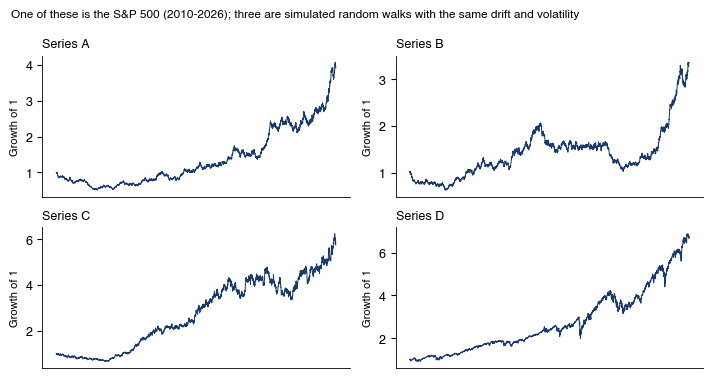

The real series is D


In [5]:
def fig_random_walk_game(seed=7):
    """S&P 500 2010-2026 printre trei mersuri aleatoare cu acelasi drift si aceeasi volatilitate."""
    p = load_close('sp500', start='2010-01-01')
    r = np.log(p).diff().dropna()
    rng = np.random.default_rng(seed)
    real_pos = rng.integers(0, 4)
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 3.8), sharex=True)
    for i, ax in enumerate(axes.flat):
        if i == real_pos:
            path = np.log(p.values / p.values[0])
        else:
            sim = rng.normal(r.mean(), r.std(), len(r))
            path = np.concatenate([[0], np.cumsum(sim)])
        ax.plot(np.arange(len(path)), np.exp(path), color=MainBlue, lw=0.7)
        ax.set_title(f'Series {"ABCD"[i]}', fontsize=9, loc='left')
        ax.set_xticks([])
        ax.set_ylabel('Growth of 1', fontsize=8)
    fig.suptitle('One of these is the S&P 500 (2010-2026); three are simulated random walks with the same drift and volatility',
                 fontsize=8.5, x=0.02, ha='left')
    plt.tight_layout()
    save_fig('ch2_random_walk_game')
    pd.Series({'real_series': 'ABCD'[real_pos]}).to_csv(os.path.join(TABLE_DIR, 'ch2_random_walk_game_answer.csv'))
    return 'ABCD'[real_pos]


answer = fig_random_walk_game()
print('The real series is', answer)

## 2. Weak-form tests on 16 series

- $\hat\rho_1$ with i.i.d. and robust standard errors, VR(q) with $z$ and $z^*$, Chow–Denning, runs, Ljung–Box $Q(10)$ and robust $\tilde Q(10)$, R/S Hurst (raw and Anis–Lloyd), Lo's $V$ and DFA.

In [6]:
def efficiency_table():
    rows = []
    for k in ORDER:
        r = rets[k]
        e = r - r.mean()
        tau1 = (e.values[1:] ** 2 * e.values[:-1] ** 2).sum() / (e ** 2).sum() ** 2
        v2, v5, v10, v20 = (variance_ratio(r, q) for q in (2, 5, 10, 20))
        cd = chow_denning(r)
        rt = runs_test(r)
        lb = robust_ljung_box(r, 10)
        h, h_al, _ = rs_hurst(r)
        V, qv = lo_modified_rs(r)
        hd, _ = dfa_hurst(r)
        rows.append(dict(market=LABELS[k], group=GROUPS[k], start=r.index[0].date(), end=r.index[-1].date(),
                         N=len(r), rho1=r.autocorr(1), rho1_se_iid=1 / np.sqrt(len(r)), rho1_se_rob=np.sqrt(tau1),
                         VR2=v2[0], z2=v2[1], zstar2=v2[2], VR5=v5[0], z5=v5[1], zstar5=v5[2],
                         VR10=v10[0], zstar10=v10[2], VR20=v20[0], zstar20=v20[2],
                         CD=cd[0], CD_p=cd[1], runs_z=rt[2], runs_p=rt[3],
                         Q10=lb[0], Q10_p=lb[1], Q10rob=lb[2], Q10rob_p=lb[3],
                         H_rs=h, H_anis_lloyd=h_al, LoV=V, LoV_q=qv, H_dfa=hd))
    t = pd.DataFrame(rows, index=ORDER)
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_efficiency_table.csv'), float_format='%.6g')
    return t


t = efficiency_table()
t.round(3).T

,sp500,stoxx,nikkei,hsi,bet,wig20,bux,px,xu100,bvsp,mxx,nsei,ssec,btc,eth,eurron
market,S&P 500 (US),Euro Stoxx 50,Nikkei 225 (Japan),Hang Seng (HK),BET (Romania),WIG20 (Poland),BUX (Hungary),PX (Czechia),BIST 100 (Turkey),Bovespa (Brazil),IPC (Mexico),Nifty 50 (India),Shanghai (China),Bitcoin,Ethereum,EUR/RON (reference rate)
group,Developed,Developed,Developed,Developed,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Emerging/frontier,Crypto,Crypto,FX
start,2000-01-04,2000-01-04,2000-01-05,2000-01-04,2000-01-06,2000-01-04,2000-01-05,2000-01-06,2000-01-05,2000-01-04,2000-01-04,2000-01-04,2000-01-05,2014-09-18,2016-01-02,2005-07-05
end,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18
N,6714,6836,6545,6583,6670,6685,6666,6682,6692,6622,6689,6606,6474,4384,3913,5352
rho1,-0.099,-0.029,-0.038,-0.004,0.109,0.018,0.037,0.052,0.005,-0.028,0.07,0.048,0.021,-0.022,-0.012,0.17
rho1_se_iid,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.012,0.015,0.016,0.014
rho1_se_rob,0.027,0.019,0.024,0.024,0.028,0.018,0.024,0.032,0.024,0.025,0.019,0.024,0.019,0.026,0.027,0.036
VR2,0.901,0.97,0.962,0.996,1.108,1.018,1.037,1.052,1.005,0.971,1.068,1.048,1.021,0.977,0.988,1.17
z2,-8.12,-2.444,-3.038,-0.332,8.827,1.469,3.008,4.215,0.386,-2.385,5.597,3.938,1.715,-1.503,-0.73,12.447


## 3. Lag-1 autocorrelation across markets

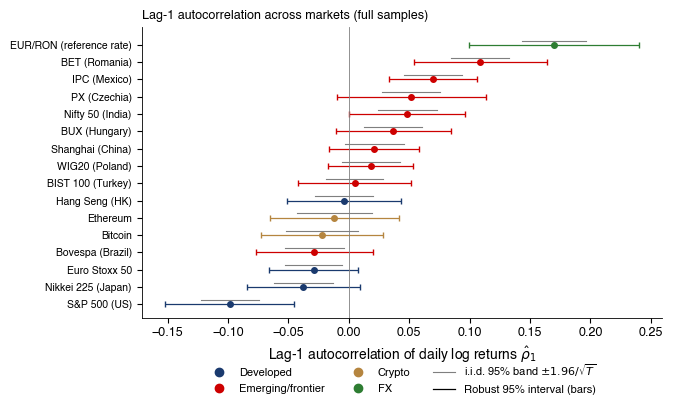

In [7]:
def fig_acf_markets(t):
    t = t.sort_values('rho1')
    y = np.arange(len(t))
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    for i, (k, row) in enumerate(t.iterrows()):
        c = GROUP_COL[row['group']]
        ax.errorbar(row['rho1'], i, xerr=1.96 * row['rho1_se_rob'], fmt='o', ms=4, color=c, capsize=2, lw=0.9)
        ax.plot([row['rho1'] - 1.96 * row['rho1_se_iid'], row['rho1'] + 1.96 * row['rho1_se_iid']], [i + 0.25] * 2,
                color=Gray, lw=0.8)
    ax.axvline(0, color=Gray, lw=0.6)
    ax.set_yticks(y, t['market'], fontsize=7.5)
    ax.set_xlabel(r'Lag-1 autocorrelation of daily log returns $\hat\rho_1$')
    handles = [plt.Line2D([], [], color=c, marker='o', ls='', label=g) for g, c in GROUP_COL.items()]
    handles += [plt.Line2D([], [], color=Gray, lw=0.8, label=r'i.i.d. 95% band $\pm 1.96/\sqrt{T}$'),
                plt.Line2D([], [], color='k', lw=0.9, label='Robust 95% interval (bars)')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    ax.set_title('Lag-1 autocorrelation across markets (full samples)', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch2_acf_markets')


fig_acf_markets(t)

## 4. Runs test

- Too few runs ($z < 0$): persistence; too many ($z > 0$): reversals.

In [8]:
t[['market', 'rho1', 'runs_z', 'runs_p']].round(3)

,market,rho1,runs_z,runs_p
sp500,S&P 500 (US),-0.099,4.335,0.000
stoxx,Euro Stoxx 50,-0.029,3.409,0.001
nikkei,Nikkei 225 (Japan),-0.038,1.972,0.049
hsi,Hang Seng (HK),-0.004,-0.167,0.867
bet,BET (Romania),0.109,-6.051,0.000
wig20,WIG20 (Poland),0.018,2.246,0.025
bux,BUX (Hungary),0.037,-0.418,0.676
px,PX (Czechia),0.052,-2.525,0.012
xu100,BIST 100 (Turkey),0.005,-0.630,0.529
bvsp,Bovespa (Brazil),-0.028,0.875,0.381


## 5. Variance ratios

- $\text{VR}(q) = 1 + 2\sum_{k<q}(1 - k/q)\rho_k$; the robust band uses $\hat\theta(q)$ of Lo and MacKinlay (1988).

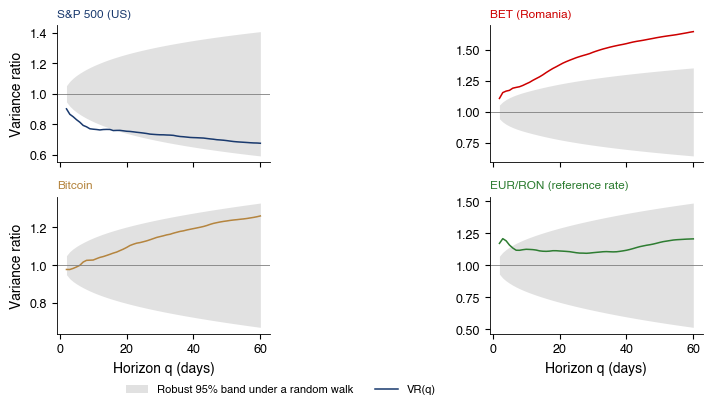

S&P 500 (US) {2: 0.901, 5: 0.83, 10: 0.767, 20: 0.753, 60: 0.674}
BET (Romania) {2: 1.108, 5: 1.173, 10: 1.225, 20: 1.377, 60: 1.644}
Bitcoin {2: 0.977, 5: 0.991, 10: 1.027, 20: 1.094, 60: 1.261}
EUR/RON (reference rate) {2: 1.17, 5: 1.157, 10: 1.124, 20: 1.111, 60: 1.205}


In [9]:
def vr_profile(r, qmax=60):
    out = []
    x = np.asarray(r, dtype=float)
    T = len(x)
    e = x - x.mean()
    den = (e ** 2).sum() ** 2
    deltas = np.array([T * (e[j:] ** 2 * e[:-j] ** 2).sum() / den for j in range(1, qmax)])
    for q in range(2, qmax + 1):
        vr = variance_ratio(r, q)[0]
        j = np.arange(1, q)
        theta = np.sum((2 * (q - j) / q) ** 2 * deltas[:q - 1])
        out.append((q, vr, 1.96 * np.sqrt(theta / T)))
    return pd.DataFrame(out, columns=['q', 'VR', 'band']).set_index('q')


def fig_vr_profile():
    sel = [('sp500', MainBlue), ('bet', IDAred), ('btc', Amber), ('eurron', Forest)]
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 4.2), sharex=True)
    res = {}
    for ax, (k, c) in zip(axes.flat, sel):
        vp = vr_profile(rets[k])
        res[k] = vp
        ax.fill_between(vp.index, 1 - vp['band'], 1 + vp['band'], color=LightGray, alpha=0.8, lw=0,
                        label='Robust 95% band under a random walk')
        ax.plot(vp.index, vp['VR'], color=c, lw=1.1, label='VR(q)')
        ax.axhline(1, color=Gray, lw=0.6)
        ax.set_title(LABELS[k], fontsize=8.5, loc='left', color=c)
    for ax in axes[1]:
        ax.set_xlabel('Horizon q (days)')
    for ax in axes[:, 0]:
        ax.set_ylabel('Variance ratio')
    h, l = axes[0, 0].get_legend_handles_labels()
    axes[1, 0].legend(h, l, loc='upper center', bbox_to_anchor=(1.05, -0.3), ncol=2, frameon=False)
    plt.tight_layout()
    save_fig('ch2_vr_profile')
    return {k: v.loc[[2, 5, 10, 20, 60]] for k, v in res.items()}


for k, v in fig_vr_profile().items():
    print(LABELS[k], v['VR'].round(3).to_dict())

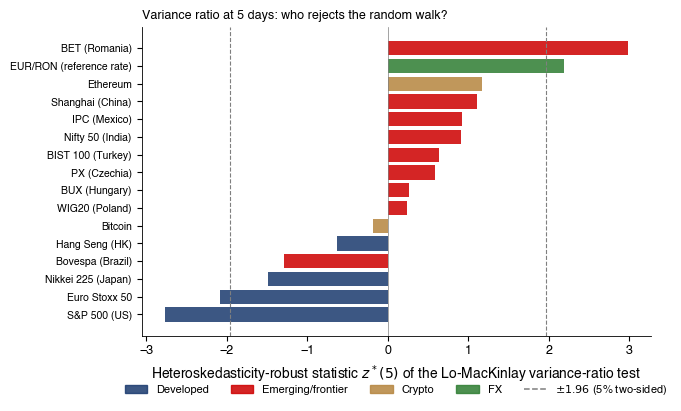

,market,zstar2,zstar5,zstar20,CD,CD_p
sp500,S&P 500 (US),-3.644,-2.772,-1.856,3.644,0.001
stoxx,Euro Stoxx 50,-1.574,-2.083,-1.952,2.238,0.097
nikkei,Nikkei 225 (Japan),-1.563,-1.485,-1.361,1.691,0.317
hsi,Hang Seng (HK),-0.170,-0.635,-0.826,0.839,0.872
bet,BET (Romania),3.836,2.980,3.311,3.836,0.001
wig20,WIG20 (Poland),1.010,0.241,0.174,1.010,0.777
bux,BUX (Hungary),1.514,0.257,0.142,1.514,0.427
px,PX (Czechia),1.634,0.592,0.974,1.634,0.350
xu100,BIST 100 (Turkey),0.198,0.637,0.624,0.637,0.949
bvsp,Bovespa (Brazil),-1.181,-1.285,-0.549,1.378,0.521


In [10]:
def fig_vr_markets(t):
    t = t.sort_values('zstar5')
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    ax.barh(np.arange(len(t)), t['zstar5'], color=[GROUP_COL[g] for g in t['group']], alpha=0.85)
    for x in (-1.96, 1.96):
        ax.axvline(x, color=Gray, ls='--', lw=0.8)
    ax.axvline(0, color=Gray, lw=0.5)
    ax.set_yticks(np.arange(len(t)), t['market'], fontsize=7.5)
    ax.set_xlabel(r'Heteroskedasticity-robust statistic $z^*(5)$ of the Lo-MacKinlay variance-ratio test')
    handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.85, label=g) for g, c in GROUP_COL.items()]
    handles.append(plt.Line2D([], [], color=Gray, ls='--', label=r'$\pm 1.96$ (5% two-sided)'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
    ax.set_title('Variance ratio at 5 days: who rejects the random walk?', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch2_vr_markets')


fig_vr_markets(t)
t[['market', 'zstar2', 'zstar5', 'zstar20', 'CD', 'CD_p']].round(3)

## 6. Long memory: R/S and DFA

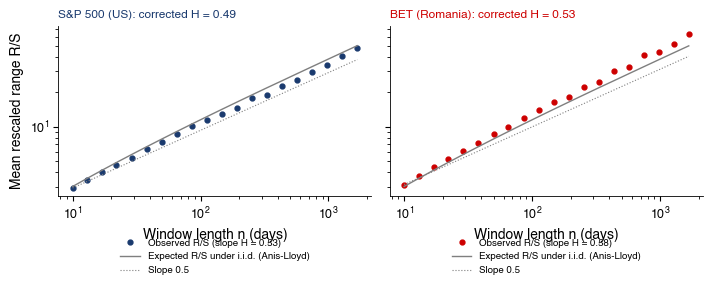

{'sp500': (np.float64(0.5304720271599295), np.float64(0.4855126734493656)),
 'bet': (np.float64(0.5781080117149741), np.float64(0.533110603511195))}

In [11]:
def fig_hurst_rs():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1), sharey=True)
    out = {}
    for ax, (k, c) in zip(axes, [('sp500', MainBlue), ('bet', IDAred)]):
        h, h_al, d = rs_hurst(rets[k])
        out[k] = (h, h_al)
        ax.loglog(d['n'], d['rs'], 'o', ms=3.5, color=c, label=f'Observed R/S (slope H = {h:.2f})')
        ax.loglog(d['n'], d['expected_rs'], '-', color=Gray, lw=1, label='Expected R/S under i.i.d. (Anis-Lloyd)')
        ax.loglog(d['n'], d['rs'].iloc[0] * (d['n'] / d['n'].iloc[0]) ** 0.5, ':', color=Gray, lw=0.8,
                  label='Slope 0.5')
        ax.set_xlabel('Window length n (days)')
        ax.set_title(f'{LABELS[k]}: corrected H = {h_al:.2f}', fontsize=8.5, loc='left', color=c)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=1, frameon=False, fontsize=7)
    axes[0].set_ylabel('Mean rescaled range R/S')
    plt.tight_layout()
    save_fig('ch2_hurst_rs')
    return out


fig_hurst_rs()

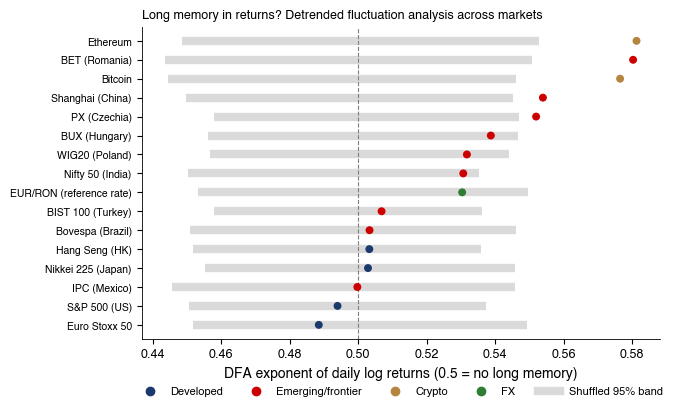

,H_dfa,band_lo,band_hi
stoxx,0.488,0.452,0.549
sp500,0.494,0.451,0.537
mxx,0.500,0.446,0.546
nikkei,0.503,0.455,0.546
hsi,0.503,0.452,0.536
bvsp,0.503,0.451,0.546
xu100,0.507,0.458,0.536
eurron,0.530,0.453,0.550
nsei,0.531,0.450,0.535
wig20,0.532,0.457,0.544


In [12]:
def shuffle_band(r, func, n_sim=200, seed=SEED):
    rng = np.random.default_rng(seed)
    x = np.asarray(r, dtype=float)
    sims = [func(rng.permutation(x)) for _ in range(n_sim)]
    return np.percentile(sims, [2.5, 97.5])


def fig_hurst_markets(t):
    band = {k: shuffle_band(rets[k], lambda x: dfa_hurst(x)[0], n_sim=100) for k in ORDER}
    t = t.assign(band_lo=[band[k][0] for k in t.index], band_hi=[band[k][1] for k in t.index]).sort_values('H_dfa')
    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    y = np.arange(len(t))
    ax.hlines(y, t['band_lo'], t['band_hi'], color=LightGray, lw=6, label='95% band of shuffled series (no memory)')
    ax.scatter(t['H_dfa'], y, color=[GROUP_COL[g] for g in t['group']], zorder=3, s=22)
    ax.axvline(0.5, color=Gray, ls='--', lw=0.8)
    ax.set_yticks(y, t['market'], fontsize=7.5)
    ax.set_xlabel('DFA exponent of daily log returns (0.5 = no long memory)')
    handles = [plt.Line2D([], [], color=c, marker='o', ls='', label=g) for g, c in GROUP_COL.items()]
    handles.append(plt.Line2D([], [], color=LightGray, lw=6, label='Shuffled 95% band'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, frameon=False)
    ax.set_title('Long memory in returns? Detrended fluctuation analysis across markets', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch2_hurst_markets')
    return t[['H_dfa', 'band_lo', 'band_hi']]


fig_hurst_markets(t).round(3)

In [13]:
# Lo's modified R/S: short memory if V is in [0.809, 1.862]
t[['market', 'H_rs', 'H_anis_lloyd', 'LoV', 'LoV_q', 'H_dfa']].round(3)

,market,H_rs,H_anis_lloyd,LoV,LoV_q,H_dfa
sp500,S&P 500 (US),0.530,0.486,1.379,0,0.494
stoxx,Euro Stoxx 50,0.539,0.494,1.038,0,0.488
nikkei,Nikkei 225 (Japan),0.542,0.497,1.283,0,0.503
hsi,Hang Seng (HK),0.564,0.519,1.055,0,0.503
bet,BET (Romania),0.578,0.533,1.961,7,0.580
wig20,WIG20 (Poland),0.563,0.518,1.241,2,0.532
bux,BUX (Hungary),0.565,0.520,1.241,3,0.539
px,PX (Czechia),0.586,0.541,1.750,4,0.552
xu100,BIST 100 (Turkey),0.549,0.504,1.163,0,0.507
bvsp,Bovespa (Brazil),0.550,0.505,1.215,0,0.503


## 7. Adaptive markets: rolling efficiency

- Rolling 500-day windows, step 21 days; DFA null band from i.i.d. Student-$t_4$ simulations.

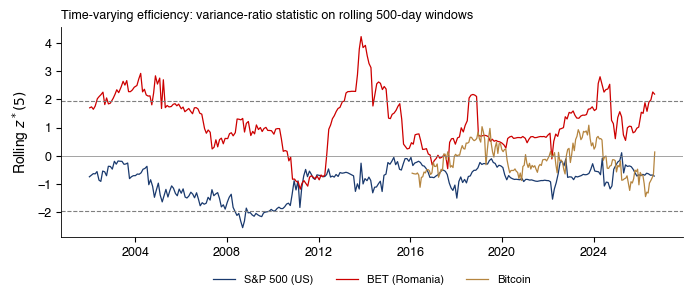

share of windows with |z*| > 1.96 {'sp500': 0.06418918918918919, 'bet': 0.22448979591836735, 'btc': 0.0}


In [14]:
WINDOW, STEP = 500, 21
ROLL = [('sp500', MainBlue), ('bet', IDAred), ('btc', Amber)]


def fig_rolling_vr():
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    out = {}
    for k, c in ROLL:
        z = rolling_stat(rets[k], lambda x: variance_ratio(x, 5)[2], WINDOW, STEP)
        out[k] = z
        ax.plot(z.index, z.values, color=c, lw=0.9, label=LABELS[k])
    for x in (-1.96, 1.96):
        ax.axhline(x, color=Gray, ls='--', lw=0.8)
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_ylabel(r'Rolling $z^*(5)$')
    ax.set_title(f'Time-varying efficiency: variance-ratio statistic on rolling {WINDOW}-day windows',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.13)
    plt.tight_layout()
    save_fig('ch2_rolling_vr')
    share = {k: float((z.abs() > 1.96).mean()) for k, z in out.items()}
    pd.DataFrame(out).to_csv(os.path.join(TABLE_DIR, 'ch2_rolling_vr.csv'))
    return share


print('share of windows with |z*| > 1.96', fig_rolling_vr())

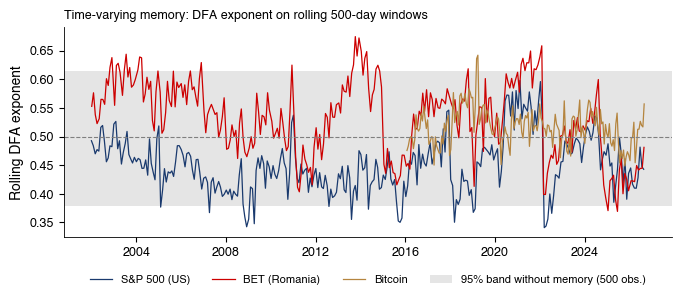

((np.float64(0.3778242224128016), np.float64(0.6143493884737028)), {'sp500': 0.06418918918918919, 'bet': 0.1292517006802721, 'btc': 0.010810810810810811})


In [15]:
def fig_rolling_hurst():
    rng = np.random.default_rng(SEED)
    null = [dfa_hurst(rng.standard_t(4, WINDOW))[0] for _ in range(300)]
    lo, hi = np.percentile(null, [2.5, 97.5])
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    out = {}
    for k, c in ROLL:
        h = rolling_stat(rets[k], lambda x: dfa_hurst(x)[0], WINDOW, STEP)
        out[k] = h
        ax.plot(h.index, h.values, color=c, lw=0.9, label=LABELS[k])
    ax.axhspan(lo, hi, color=LightGray, alpha=0.7, lw=0, label=f'95% band without memory ({WINDOW} obs.)')
    ax.axhline(0.5, color=Gray, ls='--', lw=0.8)
    ax.set_ylabel('Rolling DFA exponent')
    ax.set_title(f'Time-varying memory: DFA exponent on rolling {WINDOW}-day windows', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.13)
    plt.tight_layout()
    save_fig('ch2_rolling_hurst')
    pd.DataFrame(out).to_csv(os.path.join(TABLE_DIR, 'ch2_rolling_hurst.csv'))
    return (lo, hi), {k: float(((h < lo) | (h > hi)).mean()) for k, h in out.items()}


print(fig_rolling_hurst())

## 8. Crypto efficiency year by year

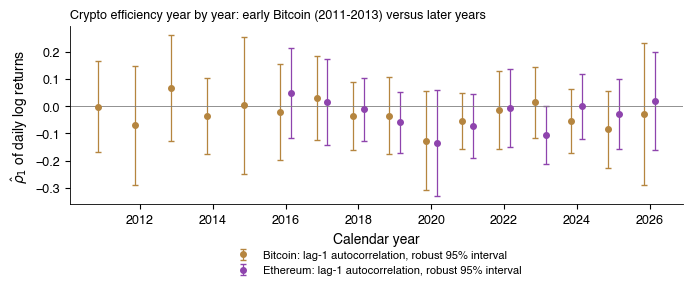

,asset,year,n,rho1,rho1_se,VR5,zstar5
0,Bitcoin,2011,364,-0.002,0.086,1.288,1.712
1,Bitcoin,2012,366,-0.071,0.112,1.084,0.371
2,Bitcoin,2013,365,0.069,0.100,1.144,0.645
3,Bitcoin,2014,365,-0.036,0.071,0.827,-1.213
4,Bitcoin,2015,365,0.004,0.129,0.894,-0.457
5,Bitcoin,2016,366,-0.021,0.091,0.966,-0.191
6,Bitcoin,2017,365,0.031,0.079,0.984,-0.103
7,Bitcoin,2018,365,-0.035,0.064,1.048,0.354
8,Bitcoin,2019,365,-0.034,0.073,0.980,-0.126
9,Bitcoin,2020,366,-0.126,0.094,0.917,-0.461


In [16]:
def crypto_yearly():
    rows = []
    for k, start in [('btc', '2011-01-01'), ('eth', '2016-01-01')]:
        r = log_returns(k, start=start)
        for y, ry in r.groupby(r.index.year):
            if len(ry) < 200:
                continue
            e = ry - ry.mean()
            tau1 = (e.values[1:] ** 2 * e.values[:-1] ** 2).sum() / (e ** 2).sum() ** 2
            vr, _, zs = variance_ratio(ry, 5)
            rows.append(dict(asset=LABELS[k], year=y, n=len(ry), rho1=ry.autocorr(1), rho1_se=np.sqrt(tau1),
                             VR5=vr, zstar5=zs))
    d = pd.DataFrame(rows)
    d.to_csv(os.path.join(TABLE_DIR, 'ch2_crypto_yearly.csv'), index=False, float_format='%.6g')
    return d


def fig_crypto_yearly():
    d = crypto_yearly()
    fig, ax = plt.subplots(figsize=(7.0, 3.1))
    for (a, c, off) in [('Bitcoin', Amber, -0.15), ('Ethereum', Purple, 0.15)]:
        s = d[d['asset'] == a]
        ax.errorbar(s['year'] + off, s['rho1'], yerr=1.96 * s['rho1_se'], fmt='o', ms=4, color=c, capsize=2,
                    lw=0.9, label=f'{a}: lag-1 autocorrelation, robust 95% interval')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_xlabel('Calendar year')
    ax.set_ylabel(r'$\hat\rho_1$ of daily log returns')
    ax.set_title('Crypto efficiency year by year: early Bitcoin (2011-2013) versus later years', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    plt.tight_layout()
    save_fig('ch2_crypto_yearly')
    return d


fig_crypto_yearly().round(3)

## 9. Semi-strong efficiency: event studies

- The worked event study (the Romanian bank tax of December 2018) is in the Chapter 0 seminar notebook, Exercise 7.

## 10. Calendar anomalies with HAC errors

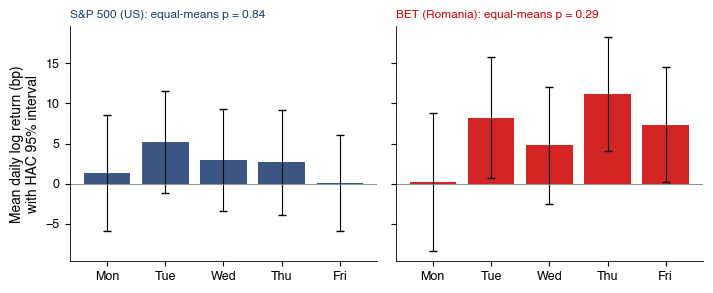

{'sp500': 0.8426436112595044, 'bet': 0.2894997651225682}


market,S&P 500 (US),BET (Romania),Euro Stoxx 50,WIG20 (Poland),BUX (Hungary)
Mon_bp,1.354,0.208,-4.005,7.848,7.385
Tue_bp,5.179,8.201,4.135,3.405,4.101
Wed_bp,2.970,4.792,1.336,-2.532,3.651
Thu_bp,2.643,11.203,1.713,1.128,2.676
Fri_bp,0.063,7.363,-1.470,-3.815,3.828
Mon_t,0.368,0.048,-0.970,1.858,1.824
Tue_t,1.606,2.130,1.183,0.850,1.082
Wed_t,0.920,1.287,0.377,-0.648,0.879
Thu_t,0.792,3.101,0.455,0.259,0.681
Fri_t,0.021,2.006,-0.399,-1.003,1.035


In [17]:
DAYS = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']


def dow_regression(r):
    """Randament zilnic pe variabile dummy pentru zilele saptamanii (fara constanta), erori Newey-West."""
    X = pd.get_dummies(r.index.dayofweek).astype(float)
    X.columns = DAYS
    X.index = r.index
    res = sm.OLS(r * 1e4, X).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    # testul egalitatii mediilor (Wald), cu aceleasi erori HAC
    R = np.zeros((4, 5))
    for i in range(4):
        R[i, 0], R[i, i + 1] = 1, -1
    w = res.wald_test(R, scalar=True)
    return res, float(w.pvalue)


def january_regression(r):
    m = np.exp(r.groupby(pd.Grouper(freq='ME')).sum()) - 1
    X = sm.add_constant(pd.Series((m.index.month == 1).astype(float), index=m.index, name='January'))
    res = sm.OLS(m * 100, X).fit(cov_type='HAC', cov_kwds={'maxlags': 3})
    return res


def turn_of_month(r):
    """Dummy pentru ultima zi de tranzactionare a lunii si primele trei zile ale lunii urmatoare (Ariel, 1987)."""
    d = pd.DataFrame({'r': r * 1e4})
    ym = d.index.to_period('M')
    rank = d.groupby(ym).cumcount()
    rank_end = d.groupby(ym).cumcount(ascending=False)
    d['tom'] = ((rank < 3) | (rank_end == 0)).astype(float)
    res = sm.OLS(d['r'], sm.add_constant(d['tom'])).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    return res


def calendar_table():
    rows = []
    for k in ['sp500', 'bet', 'stoxx', 'wig20', 'bux']:
        r = rets[k]
        res, p_eq = dow_regression(r)
        jan = january_regression(r)
        tom = turn_of_month(r)
        rows.append(dict(market=LABELS[k], **{f'{d}_bp': res.params[d] for d in DAYS},
                         **{f'{d}_t': res.tvalues[d] for d in DAYS}, dow_equal_p=p_eq,
                         jan_extra_pct=jan.params['January'], jan_t=jan.tvalues['January'],
                         tom_extra_bp=tom.params['tom'], tom_t=tom.tvalues['tom'], tom_p=tom.pvalues['tom']))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_calendar_table.csv'), float_format='%.6g')
    return t


def fig_calendar():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0), sharey=True)
    out = {}
    for ax, (k, c) in zip(axes, [('sp500', MainBlue), ('bet', IDAred)]):
        res, p_eq = dow_regression(rets[k])
        ci = res.conf_int()
        out[k] = p_eq
        ax.bar(DAYS, res.params.values, color=c, alpha=0.85)
        ax.errorbar(DAYS, res.params.values, yerr=[res.params - ci[0], ci[1] - res.params], fmt='none',
                    ecolor='k', capsize=3, lw=0.8)
        ax.axhline(0, color=Gray, lw=0.6)
        ax.set_title(f'{LABELS[k]}: equal-means p = {p_eq:.2f}', fontsize=8.5, loc='left', color=c)
    axes[0].set_ylabel('Mean daily log return (bp)\nwith HAC 95% interval')
    plt.tight_layout()
    save_fig('ch2_calendar')
    return out


print(fig_calendar())
calendar_table().round(3).T

## 11. Multiple testing: anomalies produced by chance

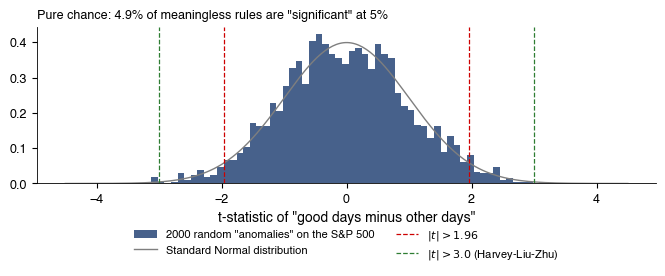

{'share_196': 0.049,
 'share_3': 0.0025,
 'max_abs_t': 3.187754688626965,
 'n': 2000}

In [18]:
def fig_multiple_testing(n_rules=2000, seed=SEED):
    """Reguli de calendar aleatoare pe S&P 500: fiecare alege la intamplare 20% din zile ca 'zile bune'."""
    rng = np.random.default_rng(seed)
    r = rets['sp500'] * 1e4
    x = r.values
    ts = []
    for _ in range(n_rules):
        mask = rng.random(len(x)) < 0.2
        d = x[mask].mean() - x[~mask].mean()
        se = np.sqrt(x[mask].var(ddof=1) / mask.sum() + x[~mask].var(ddof=1) / (~mask).sum())
        ts.append(d / se)
    ts = np.array(ts)
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    ax.hist(ts, bins=60, color=MainBlue, alpha=0.8, density=True, label=f'{n_rules} random "anomalies" on the S&P 500')
    xx = np.linspace(-4.5, 4.5, 300)
    ax.plot(xx, np.exp(-xx ** 2 / 2) / np.sqrt(2 * np.pi), color=Gray, lw=1, label='Standard Normal distribution')
    for v, lab, c in [(1.96, r'$|t| > 1.96$', IDAred), (3.0, r'$|t| > 3.0$ (Harvey-Liu-Zhu)', Forest)]:
        ax.axvline(v, color=c, ls='--', lw=0.9, label=lab)
        ax.axvline(-v, color=c, ls='--', lw=0.9)
    ax.set_xlabel('t-statistic of "good days minus other days"')
    ax.set_title(f'Pure chance: {np.mean(np.abs(ts) > 1.96):.1%} of meaningless rules are "significant" at 5%',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.22)
    plt.tight_layout()
    save_fig('ch2_multiple_testing')
    return dict(share_196=float(np.mean(np.abs(ts) > 1.96)), share_3=float(np.mean(np.abs(ts) > 3.0)),
                max_abs_t=float(np.abs(ts).max()), n=n_rules)


fig_multiple_testing()

## 12. Index-level time-series momentum

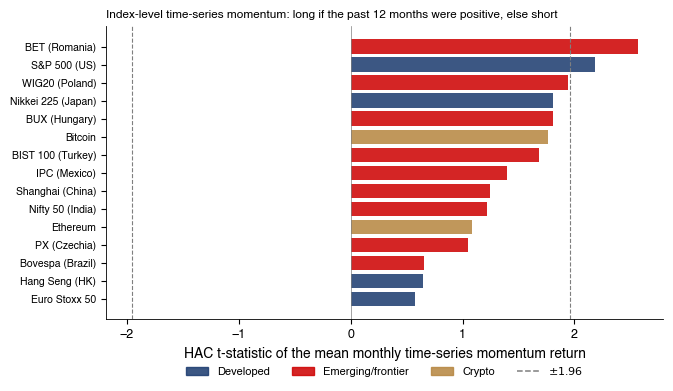

,market,group,months,tsmom_mean_pct,t_hac,sharpe_tsmom,sharpe_bh,rho1_monthly
stoxx,Euro Stoxx 50,Developed,308,0.183,0.572,0.121,0.057,0.045
hsi,Hang Seng (HK),Developed,308,0.218,0.643,0.124,0.079,0.044
bvsp,Bovespa (Brazil),Emerging/frontier,308,0.273,0.656,0.139,0.390,0.107
px,PX (Czechia),Emerging/frontier,308,0.398,1.047,0.248,0.343,0.103
eth,Ethereum,Crypto,116,3.660,1.083,0.419,0.545,0.157
nsei,Nifty 50 (India),Emerging/frontier,308,0.461,1.219,0.256,0.515,0.022
ssec,Shanghai (China),Emerging/frontier,308,0.548,1.243,0.273,0.103,0.084
mxx,IPC (Mexico),Emerging/frontier,308,0.431,1.394,0.307,0.530,0.036
xu100,BIST 100 (Turkey),Emerging/frontier,308,0.884,1.683,0.332,0.593,-0.083
btc,Bitcoin,Crypto,132,3.420,1.765,0.604,0.789,0.132


In [19]:
def tsmom_table():
    rows = []
    for k in [m for m in ORDER if m != 'eurron']:
        p = load_close(k)
        m = np.log(p.resample('ME').last()).diff().dropna()
        sig = np.sign(m.rolling(12).sum().shift(1))            # semnul randamentului pe ultimele 12 luni
        s = (sig * m).dropna()
        res = sm.OLS(s * 100, np.ones(len(s))).fit(cov_type='HAC', cov_kwds={'maxlags': 6})
        bh = m.loc[s.index]
        rows.append(dict(market=LABELS[k], group=GROUPS[k], months=len(s),
                         tsmom_mean_pct=res.params.iloc[0], t_hac=res.tvalues.iloc[0],
                         sharpe_tsmom=np.sqrt(12) * s.mean() / s.std(), sharpe_bh=np.sqrt(12) * bh.mean() / bh.std(),
                         rho1_monthly=m.autocorr(1)))
    t = pd.DataFrame(rows, index=[m for m in ORDER if m != 'eurron'])
    t.to_csv(os.path.join(TABLE_DIR, 'ch2_tsmom_table.csv'), float_format='%.6g')
    return t


def fig_tsmom():
    t = tsmom_table().sort_values('t_hac')
    fig, ax = plt.subplots(figsize=(6.8, 4.0))
    ax.barh(np.arange(len(t)), t['t_hac'], color=[GROUP_COL[g] for g in t['group']], alpha=0.85)
    for x in (-1.96, 1.96):
        ax.axvline(x, color=Gray, ls='--', lw=0.8)
    ax.axvline(0, color=Gray, lw=0.5)
    ax.set_yticks(np.arange(len(t)), t['market'], fontsize=7.5)
    ax.set_xlabel('HAC t-statistic of the mean monthly time-series momentum return')
    handles = [plt.Rectangle((0, 0), 1, 1, color=GROUP_COL[g], alpha=0.85, label=g)
               for g in ['Developed', 'Emerging/frontier', 'Crypto']]
    handles.append(plt.Line2D([], [], color=Gray, ls='--', label=r'$\pm 1.96$'))
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=False)
    ax.set_title('Index-level time-series momentum: long if the past 12 months were positive, else short',
                 fontsize=8.5, loc='left')
    plt.tight_layout()
    save_fig('ch2_tsmom')
    return t


fig_tsmom().round(3)